In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns

from pathlib import Path


# Sobe de codigos/ para a raiz do projeto
BASE = Path.cwd().parent         
DADOS = BASE / "dados" / "brutos"
FIGURAS = BASE / "resultados" / "figuras"


_Tratando dados e criando dataframes_

In [33]:
employment_rate = pd.read_csv(DADOS/"employment_rate_japan.csv")

#Tirar o -01-01
employment_rate["observation_date"] = employment_rate['observation_date'].astype(str).str[:4].astype(int)
#Mudar nome das colunas
employment_rate = employment_rate.rename(columns= {'observation_date':'Year', 'LREM64TTJPM156S': 'taxa de emprego'})

#Mudar taxa para decimal
employment_rate["taxa de emprego"] = employment_rate['taxa de emprego'] /100

#Selecionando o período necessário
employment_rate = employment_rate[(employment_rate["Year"] >= 1993) & (employment_rate['Year']<= 2019)]

employment_rate


,Year,taxa de emprego
23,1993,0.695679
24,1994,0.693441
25,1995,0.692519
26,1996,0.695659
27,1997,0.700652
28,1998,0.695617
29,1999,0.690213
30,2000,0.689893
31,2001,0.688396
32,2002,0.683137


In [11]:
#Objetivo aqui é transformar os dados de hiato de produto em um dataframe para melhor trabalhar com os dados
data_gap = pd.read_excel(DADOS/"gap.xlsx", header=2)
# Selecionamos apenas as colunas de interesse
df_gap = data_gap[["Quarterly", "Output gap"]]
#Eliminamos as linhas que não possuiam dados
df_gap = df_gap.drop([0,1])

#Como nossa análise será pautada por ano, pegaremos apenas os resultados dos últimos trimestres
gap_ano = df_gap[df_gap['Quarterly'].str.contains('4Q$', na = False)]

#Agora transformaremos o Dataframe para que os anos sejam o novo índice:
gap_ano['Quarterly'] = gap_ano['Quarterly'].str.replace(".4Q", '',regex=False).astype(int)
gap_ano = gap_ano.rename(columns={'Quarterly':'Year'})
#Selecionando o período necessário
gap_ano = gap_ano[(gap_ano["Year"]>= 1993) & (gap_ano["Year"]<= 2019)]
gap_ano.head()


C:\Users\tgu12\AppData\Local\Temp\ipykernel_20044\2815982801.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gap_ano['Quarterly'] = gap_ano['Quarterly'].str.replace(".4Q", '',regex=False).astype(int)


,Year,Output gap
45,1993,-0.920757
49,1994,-1.145398
53,1995,-0.637239
57,1996,0.251554
61,1997,-0.714214


In [ ]:
#Transformando em um data frame apenas
df_combinado = pd.merge(gap_ano, employment_rate, on='Year', how='inner')
df_combinado.head()

,Year,Output gap,taxa de emprego
0,1993,-0.920757,0.695679
1,1994,-1.145398,0.693441
2,1995,-0.637239,0.692519
3,1996,0.251554,0.695659
4,1997,-0.714214,0.700652


In [19]:
print(df_combinado.columns)

Index(['Year', 'Output gap', 'taxa de emprego'], dtype='object')


_Gráficos_

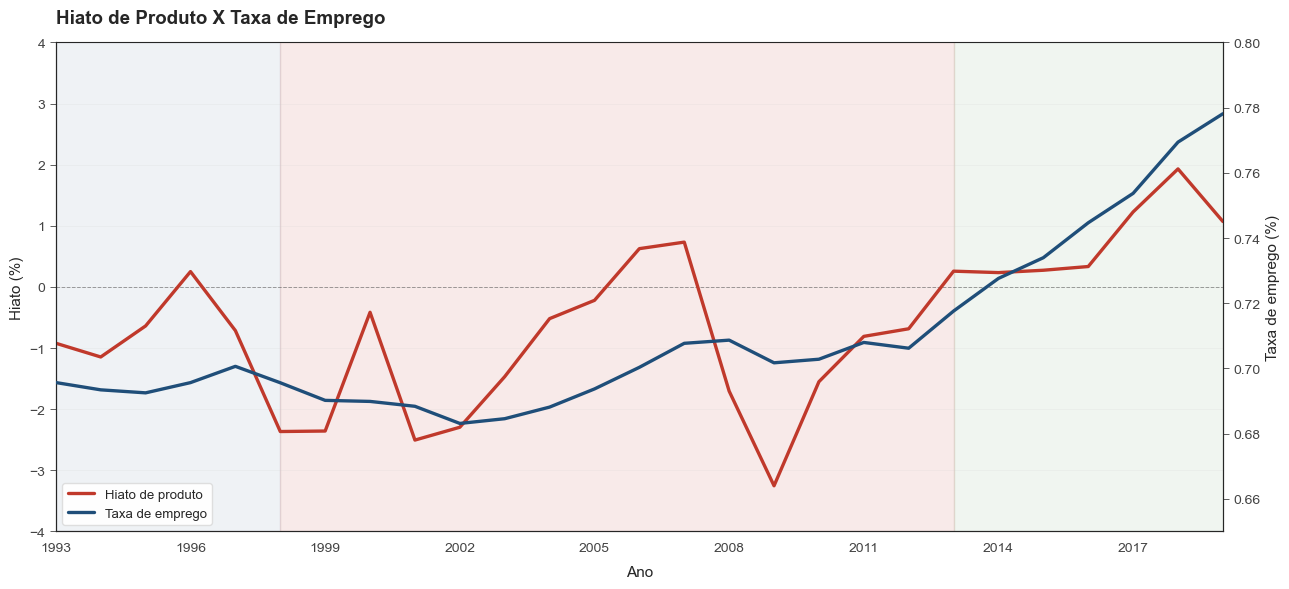

In [35]:
sns.set_style('white')
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 10, 'axes.titlesize': 13,
    'axes.labelsize': 11, 'legend.fontsize': 9,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
})

# --- limpeza ---
df = df_combinado.copy()
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')
df['Output gap'] = pd.to_numeric(df['Output gap'], errors='coerce')
df['taxa de emprego'] = pd.to_numeric(df['taxa de emprego'], errors='coerce')
df = df.dropna(subset=['Year']).copy()
df['Year'] = df['Year'].astype(int)

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')
ax2 = ax.twinx()   # eixo y da direita

COR_GAP = '#c0392b'
ax.axvspan(1993, 1998, alpha=0.07, color='#1f4e79', zorder=0)
ax.axvspan(1998, 2013, alpha=0.10, color=COR_GAP,   zorder=0)
ax.axvspan(2013, 2021, alpha=0.07, color='#2e7d32', zorder=0)

ax.set_ylim(-4, 4)
ax2.set_ylim(0.65,0.8)        # ajuste à faixa real da taxa de emprego
ax.set_xlim(1993, 2019)

ax.axhline(0, color='#333', linewidth=0.7, linestyle='--', alpha=0.45, zorder=1)

# linhas
l1 = ax.plot(df['Year'], df['Output gap'], linewidth=2.4,
             color='#c0392b', zorder=3, label='Hiato de produto')
l2 = ax2.plot(df['Year'], df['taxa de emprego'], linewidth=2.4,
              color='#1f4e79', zorder=3, label='Taxa de emprego')

ax.set_xticks(range(1993, 2020, 3))
ax.set_xlabel('Ano', fontsize=11, labelpad=8)
ax.set_ylabel('Hiato (%)', fontsize=11)
ax2.set_ylabel('Taxa de emprego (%)', fontsize=11)
ax.set_title('Hiato de Produto X Taxa de Emprego',
             fontsize=13.5, weight='bold', pad=14, loc='left')

# legenda única juntando as duas linhas
linhas = l1 + l2
ax.legend(linhas, [l.get_label() for l in linhas], loc='lower left',
          framealpha=0.95, fontsize=9.5, frameon=True, edgecolor='#ddd')

ax.grid(axis='y', alpha=0.22, linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.tick_params(colors='#444', length=4, width=0.6)
ax2.tick_params(colors='#444', length=4, width=0.6)

plt.tight_layout()
plt.savefig(FIGURAS / 'output_X_taxaemprego.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()

In [34]:
print(df_combinado['taxa de emprego'].describe())
print(df_combinado[['Year', 'taxa de emprego']].head(10))

count    27.000000
mean      0.709346
std       0.025657
min       0.683137
25%       0.692980
50%       0.700652
75%       0.713148
max       0.778133
Name: taxa de emprego, dtype: float64
   Year  taxa de emprego
0  1993         0.695679
1  1994         0.693441
2  1995         0.692519
3  1996         0.695659
4  1997         0.700652
5  1998         0.695617
6  1999         0.690213
7  2000         0.689893
8  2001         0.688396
9  2002         0.683137


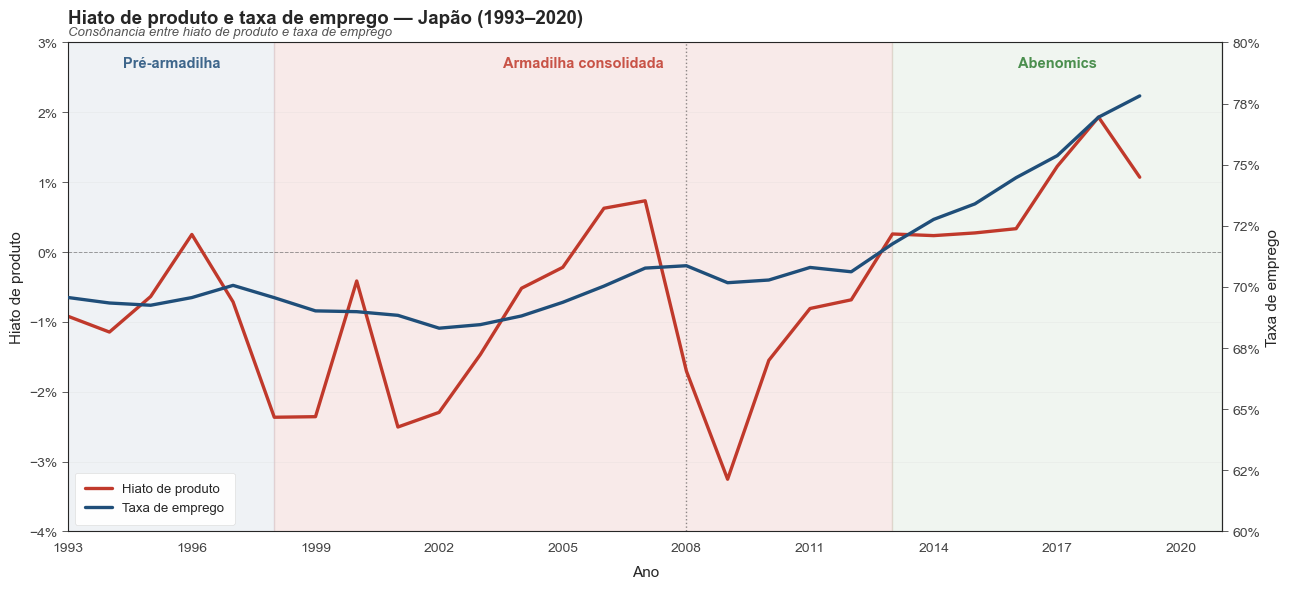

In [40]:
sns.set_style('white')
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 10, 'axes.titlesize': 13,
    'axes.labelsize': 11, 'legend.fontsize': 9,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
})

# --- limpeza ---
df = df_combinado.copy()
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')
df['Output gap'] = pd.to_numeric(df['Output gap'], errors='coerce')
df['taxa de emprego'] = pd.to_numeric(df['taxa de emprego'], errors='coerce') * 100
df = df.dropna(subset=['Year']).copy()
df['Year'] = df['Year'].astype(int)

COR_GAP = '#c0392b'
COR_EMP = '#1f4e79'

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')
ax2 = ax.twinx()   # eixo y da direita (taxa de emprego)

# faixas de fundo
ax.axvspan(1993, 1998, alpha=0.07, color='#1f4e79', zorder=0)
ax.axvspan(1998, 2013, alpha=0.10, color=COR_GAP,   zorder=0)
ax.axvspan(2013, 2021, alpha=0.07, color='#2e7d32', zorder=0)

ax.set_ylim(-4, 3)
ax2.set_ylim(60, 80)        # ajuste à faixa real da taxa de emprego
ax.set_xlim(1993, 2021)

# rótulos dos períodos
y_label = 2.65
ax.text(1995.5, y_label, 'Pré-armadilha',
        ha='center', fontsize=10.5, color='#1f4e79', weight='bold', alpha=0.85)
ax.text(2005.5, y_label, 'Armadilha consolidada',
        ha='center', fontsize=10.5, color=COR_GAP, weight='bold', alpha=0.85)
ax.text(2017, y_label, 'Abenomics',
        ha='center', fontsize=10.5, color='#2e7d32', weight='bold', alpha=0.85)

# linha do zero e marcação de 2008
ax.axhline(0, color='#333', linewidth=0.7, linestyle='--', alpha=0.45, zorder=1)
ax.axvline(2008, color='#333', linewidth=1.0, linestyle=':', alpha=0.55, zorder=1)
ax.annotate('Crise financeira\nglobal (2008)',
            xy=(2008, -4.5), xytext=(2008.5, -5.4),
            fontsize=8.5, ha='left', va='center', color='#333', style='italic',
            arrowprops=dict(arrowstyle='-', color='#888', alpha=0.6, lw=0.7))

# as duas linhas (sem preenchimento)
l1 = ax.plot(df['Year'], df['Output gap'], linewidth=2.4,
             color=COR_GAP, zorder=3, label='Hiato de produto')
l2 = ax2.plot(df['Year'], df['taxa de emprego'], linewidth=2.4,
              color=COR_EMP, zorder=3, label='Taxa de emprego')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xticks(range(1993, 2022, 3))

ax.set_xlabel('Ano', fontsize=11, labelpad=8)
ax.set_ylabel('Hiato de produto', fontsize=11)
ax2.set_ylabel('Taxa de emprego', fontsize=11)
ax.set_title('Hiato de produto e taxa de emprego — Japão (1993–2020)',
             fontsize=13.5, weight='bold', pad=14, loc='left')

ax.text(0.0, 1.015,
        'Consônancia entre hiato de produto e taxa de emprego',
        transform=ax.transAxes, fontsize=9.5, style='italic', color='#555', ha='left')

# legenda única juntando as duas linhas
linhas = l1 + l2
legend = ax.legend(linhas, [l.get_label() for l in linhas], loc='lower left',
                   framealpha=0.95, fontsize=9.5, frameon=True,
                   edgecolor='#ddd', borderpad=0.8)
legend.get_frame().set_linewidth(0.5)

ax.grid(axis='y', alpha=0.22, linewidth=0.5)
ax.grid(axis='x', visible=False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_color('#999')
ax.spines['bottom'].set_color('#999')
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)
ax.tick_params(colors='#444', length=4, width=0.6)
ax2.tick_params(colors='#444', length=4, width=0.6)

plt.tight_layout()
plt.savefig(FIGURAS / 'output_X_taxaemprego.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()